# Dermatology Classification Model

Author: Rayssa Coelho Silva

# 1. Setup and Imports

1.1 Installation of requirements.txt

In [5]:
#!pip install -r requirements.txt

1.2 Library Imports

In [ ]:
import pandas as pd                                             # manipulate data (dataframe)
import numpy as np                                              # calculations
import wandb                                                    # track, visualize and manage ML experiments
import kagglehub                                                # access datasets from Kaggle
import shutil                                                   # used to manipulate files and directories
import os                                                       # for handling file paths and directories
import seaborn as sns                                           # graphics
import random                                                   # for generating random numbers
import matplotlib.pyplot as plt                                 # graphics
import joblib                                                   # for saving and loading models
import torch                                                    # for working with tensors and deep learning
import torch.nn as nn                                           # for building neural networks
import torch.optim as optim                                     # for optimizing the weights of the neural network
import statsmodels.api as sm                                    # for statistical analysis


from torch.utils.data import DataLoader, TensorDataset          # para criar dataloaders a partir de tensores
from pyparsing import col                                       # para lidar com colunas em parsing de texto
from dotenv import load_dotenv                                  # for loading environment variables from a .env file
from sklearn.model_selection import train_test_split            # for splitting the data into training and testing sets
from sklearn.impute import SimpleImputer                        # for handling missing values
from sklearn.ensemble import RandomForestRegressor              # regression model based on decision trees
from sklearn.linear_model import LinearRegression               # linear regression model
from sklearn.metrics import mean_squared_error                  # for calculating the model's error
from sklearn.preprocessing import MinMaxScaler                  # for normalizing the data
from sklearn.feature_selection import mutual_info_classif       # for calculating feature importance using mutual information
from sklearn.ensemble import RandomForestClassifier             # classification model based on decision trees
from sklearn.preprocessing import StandardScaler                # for standardizing the data
from sklearn.linear_model import LogisticRegression             # logistic regression model for classification
from sklearn.inspection import permutation_importance           # for calculating feature importance using permutation importance
from statsmodels.stats.outliers_influence import variance_inflation_factor  # for calculating the VIF (Variance Inflation Factor) and detecting multicollinearity

print("All libraries imported successfully.")


Todas as bibliotecas importadas com sucesso.


1.3 Setup Used

In [ ]:
# Configure seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

config = {
    "data": {
        "target_col": "class",
        "test_size": 0.2,
        "random_state": 42,
        "imputation_strategy": "median",
        "missing_threshold": 0.5
    },
    "model": {
        "hidden_sizes": [64, 32],
        "output_dim": 6,
        "dropout": 0.2
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 150,
        "early_stopping_patience": 10
        
    }
}

1.4 Sweep Configuration for Training

In [12]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "val_acc",
        "goal": "maximize"
    },
    "parameters": {
        "learning_rate": {
            "values": [0.01, 0.001, 0.0001]
        },
        "dropout": {
            "values": [0.1, 0.2, 0.3, 0.5]
        },
        "hidden_sizes": {
            "values": [
                [64, 32],
                [128, 64],
                [256, 128]
            ]
        },
        "batch_size": {
            "values": [16, 32, 64]
        }
    }
}

# 2. Accessing the Dataset

2.1 Loading dataset from Kaggle

In [ ]:
path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification") 
print("Path for the dataset files:", path)

Path para os arquivos do dataset: C:\Users\rayco\.cache\kagglehub\datasets\olcaybolat1\dermatology-dataset-classification\versions\5


In [ ]:
# load the environment variables from the .env file
load_dotenv()

# path returned by kagglehub
source_path = path  

# destination inside your project
dest_path = os.path.join(os.getcwd(), "data")

# copy everything to the data folder
shutil.copytree(source_path, dest_path, dirs_exist_ok=True)

print("Dataset copied to:", dest_path)

Dataset copiado para: c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\projeto_avaliacao\notebooks\data


2.2 Raw data

In [ ]:
df_raw = pd.read_csv( # reads the CSV file
     "data/dermatology_database_1.csv",
    low_memory=False # avoids warnings of mixed data types
)
print(f"Shape: {df_raw.shape}") # shows the number of rows and columns
print(f"Columns: {list(df_raw.columns[:5])}...") # shows the names of the first 5 columns
df_raw.head() # shows the first 5 rows of the dataframe

Shape: (366, 35)
Columns: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon']...


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [ ]:
df_raw.describe() # shows basic statistics of the numeric columns

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


2.3 Login into W&B and Creation Artefact

In [ ]:
API_KEY = os.getenv("WANDB_API_KEY") # gets the W&B API key from the .env file
wandb.login(key=API_KEY) 

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\rayco\_netrc
wandb: Currently logged in as: raycoelho (raycoelho-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Initializes a new run in W&B for this data loading step
wandb.init(
    project="mlops-project-dermatology", # project name in W&B
    job_type="load_raw", # job type (can be "load_raw", "preprocess", "train", etc.)
    name="load_raw" # run name (can be "load_raw", "preprocess", "train", etc.)
)

# Creates a new artifact for the raw dataset
artifact = wandb.Artifact( # creates a new artifact
    name="raw_data", # artifact name (versioned automatically)
    type="dataset", # artifact type (can be "dataset", "model", "code", etc.)
    description="Dermatology raw dataset from Kaggle"
)
temp_path = "temp_raw.csv" # temporary path to save the CSV of the dataframe
df_raw.to_csv(temp_path, index=False) # saves the dataframe as CSV without the index
artifact.add_file(temp_path) # adds the CSV file to the artifact

# Log the artifact to W&B
wandb.log_artifact(artifact) # uploads the artifact to W&B

# Log summary statistics visible on the W&B dashboard
wandb.summary["rows"] = len(df_raw) # number of rows
wandb.summary["columns"] = list(df_raw.columns) # list of columns (can be truncated if too long)
wandb.finish() # finalizes the current run in W&B

print("Raw data saved as artifact in W&B.")

rows,366


Data bruto salvo como artifact no W&B.


2.4 Exploratory Data Analysis 

Text(0.5, 1.0, 'Distribution of Classes')

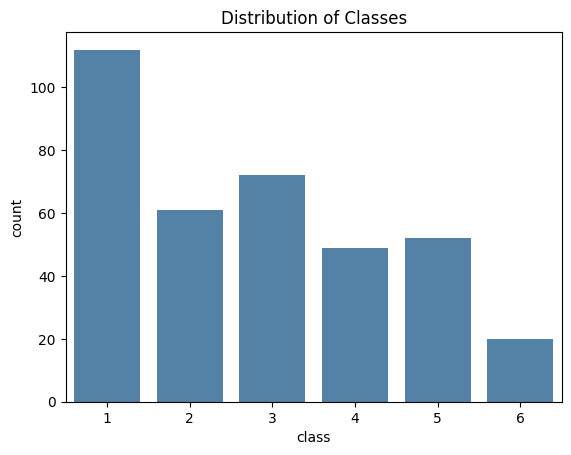

In [ ]:
# Graphic for a bar chart to visualize the distribution of classes
sns.countplot(x=df_raw['class'], color="steelblue") # shows the distribution of classes (diseases) in the dataset using a bar chart
plt.title("Distribution of Classes") # title of the chart

Text(0.5, 0.98, 'Histograms of Numerical Features')

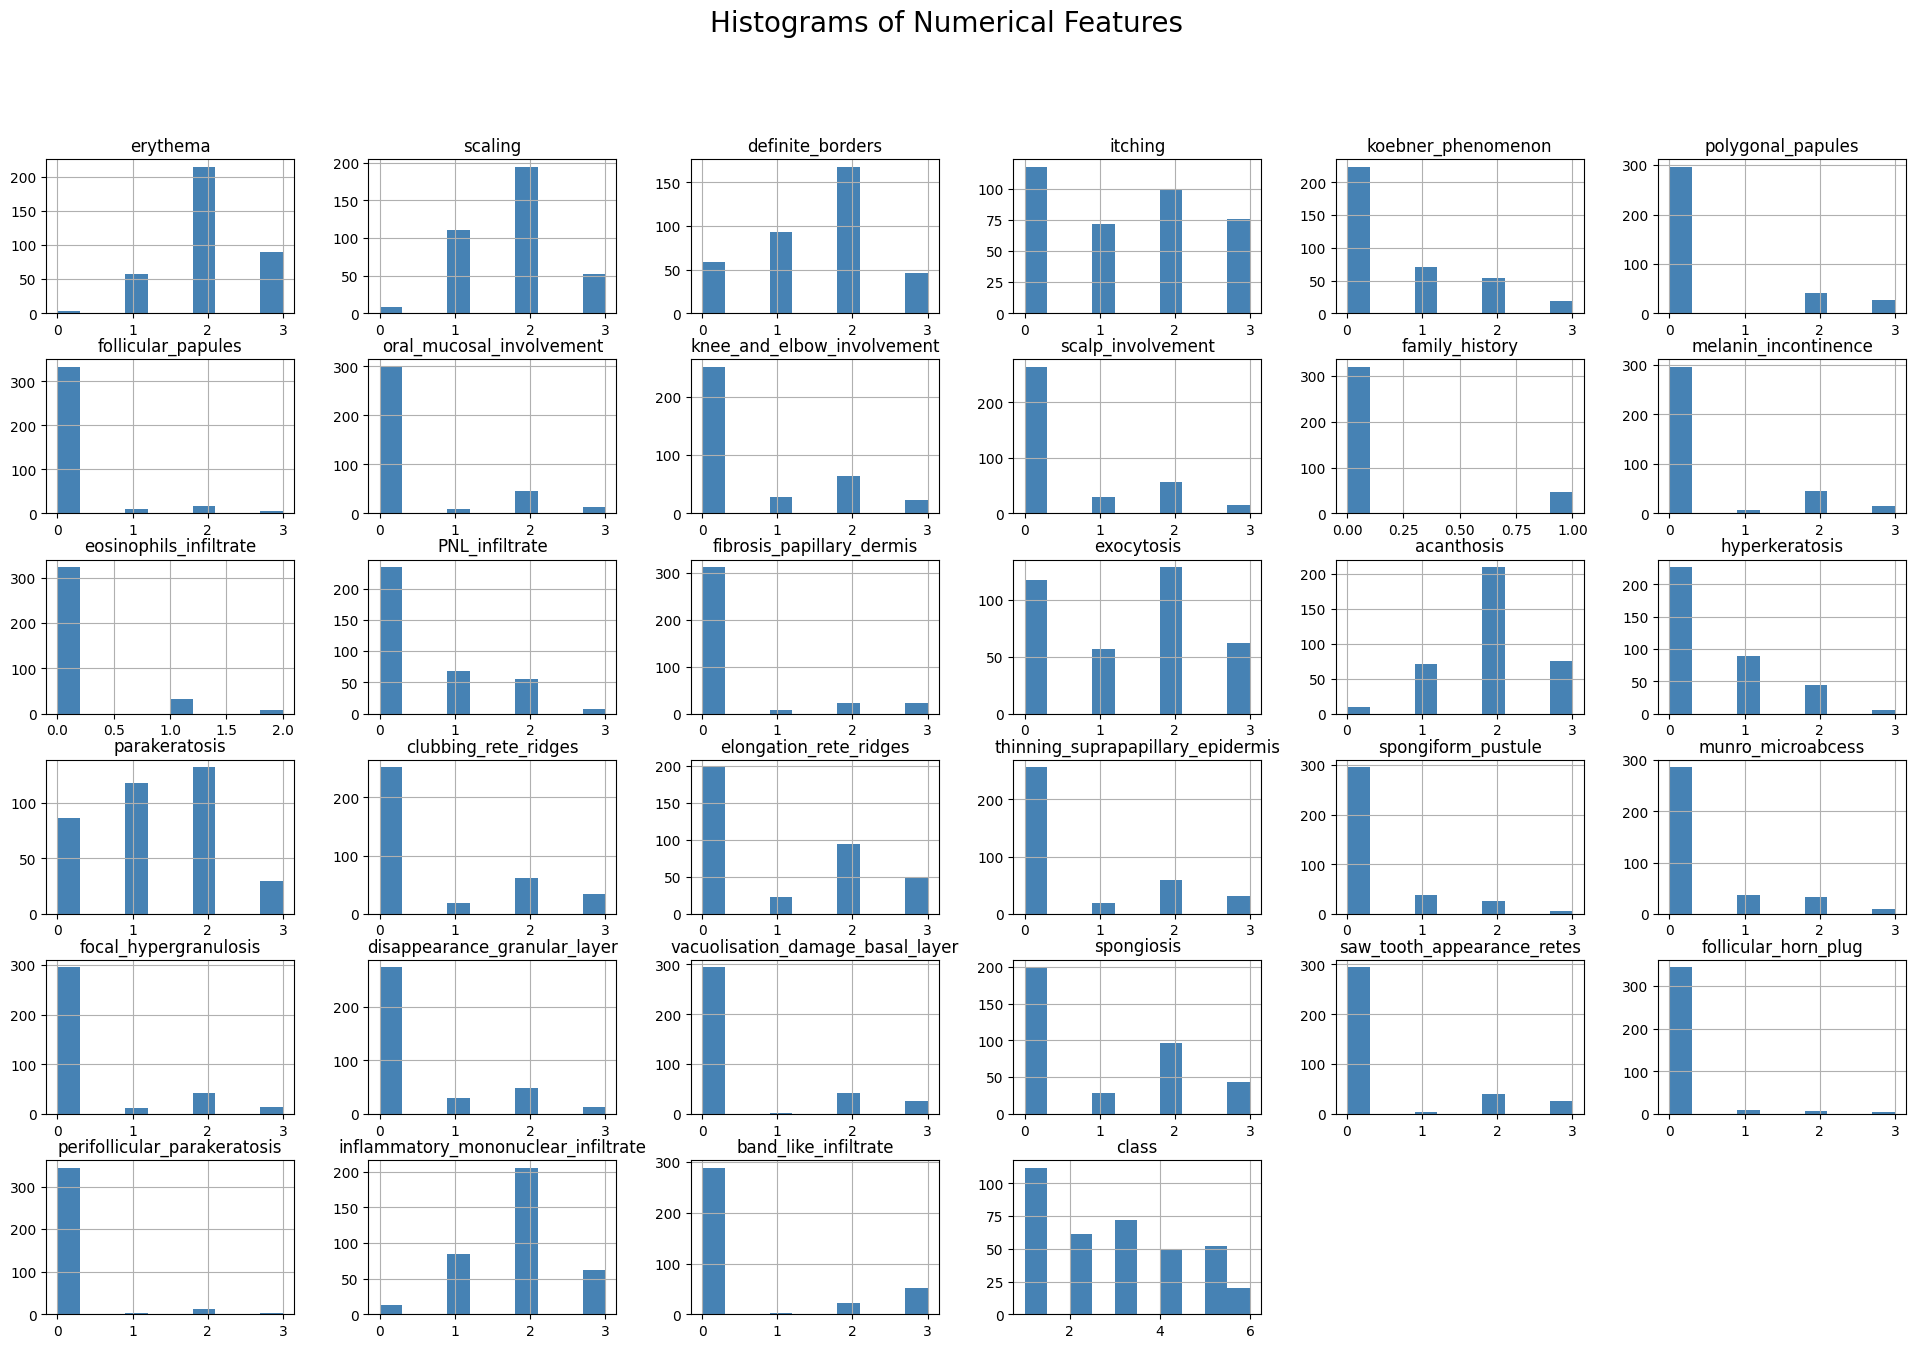

In [ ]:
# Histograms for numerical columns
df_raw.hist(figsize=(24,15), color="steelblue") # shows histograms for all numerical columns in the dataframe, with a large figure size for better visualization
plt.suptitle("Histograms of Numerical Features", fontsize=20) # general title for the histograms

Text(0, 0.5, 'Age')

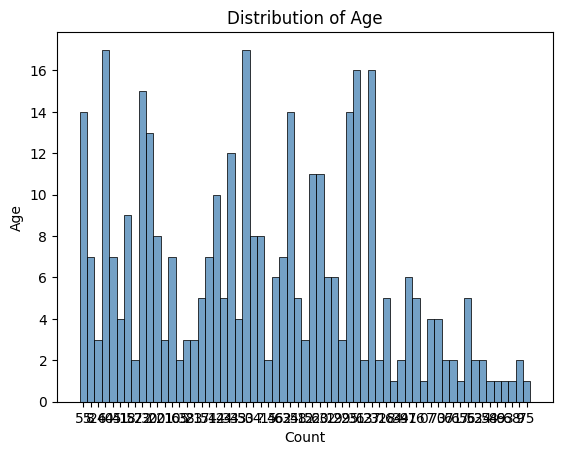

In [ ]:
sns.histplot(x=df_raw['age'], color="steelblue") # Shows the distribution of age in the dataset using a histogram
plt.title("Distribution of Age") # Title of the chart
plt.xlabel("Count") # Label of the x-axis
plt.ylabel("Age") # Label of the y-axis

# 3. Data Cleaning

3.1 Removal of duplicates and missing values

In [ ]:
# Remove duplicates and handle missing values

# Essential correction: replace '?' with NaN before anything else
df_raw['age'] = df_raw['age'].replace('?', np.nan) # replace '?' with NaN so that they can be treated as missing values
df_raw['age'] = pd.to_numeric(df_raw['age'])  # converts to number

def remove_duplicates(df): # remove rows duplicates from the dataframe
    before = len(df)        # save the original number of rows
    df = df.drop_duplicates() # remove all duplicate rows from the dataframe
    print(f"Removed {before - len(df)} duplicates") # print how many rows were removed
    return df # return the dataframe without duplicates

def handle_missing_values(df, strategy=config["data"]["imputation_strategy"], threshold=config["data"]["missing_threshold"]): # treats missing values
    missing_frac = df.isnull().median() # calculates the fraction of missing values per column
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist() # identifies columns with more than 50% of missing values
    df = df.drop(columns=cols_to_drop) # removes these columns from the dataframe
    print(f"Dropped columns: {cols_to_drop}") # prints which columns were removed
    numeric_cols = df.select_dtypes(include=[np.number]).columns # selects only the numeric columns
    imputer = SimpleImputer(strategy=strategy) # creates an imputer to fill missing values using the chosen strategy (median)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols]) # fills missing values in numeric columns using the chosen strategy (mean, median, etc.)
    cat_cols = df.select_dtypes(include=['object']).columns # selects only the object-type columns
    df[cat_cols] = df[cat_cols].fillna('missing') # fills missing values with 'missing'
    return df

#executando
df_clean = remove_duplicates(df_raw) # remove duplicate rows
df_clean = handle_missing_values(df_clean, strategy=config["data"]["imputation_strategy"], threshold=config["data"]["missing_threshold"]) # treat missing values
print(f"Dataset in clean format: {df_clean.shape}") # shows the number of rows and columns of the clean dataset

# confirm that no null values remain
print(f"Remaining null values: {df_clean.isnull().sum().sum()}")

Removed 0 duplicates
Dropped columns: []
Dataset no formato limpo: (366, 35)
Nulos restantes: 0


3.2 Viewing and recording the removal

Text(0, 0.5, 'Count')

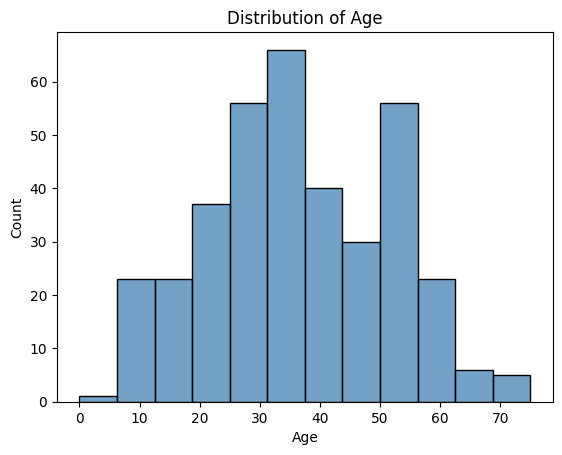

In [ ]:
# Graphic for a histogram to visualize the distribution of ages
sns.histplot(x=df_clean['age'], color="steelblue") # shows the distribution of ages in the dataset using a histogram
plt.title("Distribution of Age") # title of the chart
plt.xlabel("Age") # label of the x-axis
plt.ylabel("Count") # label of the y-axis

In [ ]:
wandb.init(project="mlops-project-dermatology", job_type="clean_data", name="clean_data") # starts a new run in w&b
artifact = wandb.Artifact("clean_data", type="dataset") # new artifact for the clean dataset
temp_clean = "temp_clean.csv" # temporary path to save the CSV of the clean dataframe
df_clean.to_csv(temp_clean, index=False) # saves the dataframe as a CSV and prevents the index from being saved as a column
artifact.add_file(temp_clean) # adds the CSV file of the clean dataframe to the artifact
wandb.log_artifact(artifact) # uploads the artifact to W&B
wandb.summary["clean_rows"] = len(df_clean) # adds to the W&B summary the number of rows in the clean dataset
wandb.finish() # finalizes the current run in W&B
print("Dataset clean saved as artifact in W&B.")

clean_rows,366


Dataset limpo salvo como artifact no W&B.


3.3 Handling outliers

In [ ]:
def detect_and_treat_outliers_iqr(df_clean, columns, strategy='capping', fator=1.5): # function to detect and treat outliers using the interquartile range (IQR) method
    # Detect and treat outliers via IQR.
    # Strategies: 'capping' | 'mediana' | 'remover', serves to replace outliers with the limits or the median, or to remove the rows with outliers
    df_out = df_clean.copy() # to not modify the original

    for col in columns:
        Q1 = df_out[col].quantile(0.25) # first quartile
        Q3 = df_out[col].quantile(0.75) # third quartile
        IQR = Q3 - Q1 # interquartile range
        li = Q1 - fator * IQR   # lower limit
        ls = Q3 + fator * IQR   # upper limit

        outliers = ((df_out[col] < li) | (df_out[col] > ls)).sum() # count how many outliers exist in this column by comparing with the limits
        print(f"[{col}] Q1={Q1:.1f} | Q3={Q3:.1f} | Limits: [{li:.1f}, {ls:.1f}] | Outliers: {outliers}") # print the quartiles, limits, and number of outliers found

        if strategy == 'capping': # replace outliers with the limits
            df_out[col] = df_out[col].clip(lower=li, upper=ls)   # replace with the limits

        elif strategy == 'median': # replace outliers with the median
            mediana = df_out[col].median()
            df_out[col] = df_out[col].where((df_out[col] >= li) & (df_out[col] <= ls), mediana) # replace outliers with the median using where to keep values within limits and replace outliers

        elif strategy == 'remove': # remove rows with outliers
            df_out = df_out[(df_out[col] >= li) & (df_out[col] <= ls)] # keep only rows where values are within limits, removing rows with outliers

    return df_out
   
# execute only 'age' has a continuous scale; the rest are ordinal (0-3)
colunas_alvo = ['age'] # define which columns will be treated for outliers (only 'age' in this case, as the others are ordinal with few possible values)

df_out = detect_and_treat_outliers_iqr(df_clean, columns=colunas_alvo, strategy='capping') # treat outliers using the interquartile range (IQR) method and the capping strategy (replace with limits)

print(f"\nShape after treatment: {df_out.shape}") # shows the number of rows and columns of the dataset after outlier treatment
print(f"Age — min: {df_out['age'].min():.0f} | max: {df_out['age'].max():.0f}") # shows the minimum and maximum values of the 'age' column after outlier treatment to confirm that extreme values were treated
       


[age] Q1=25.0 | Q3=48.0 | Limites: [-9.5, 82.5] | Outliers: 0

Shape após tratamento: (366, 35)
Age — min: 0 | max: 75


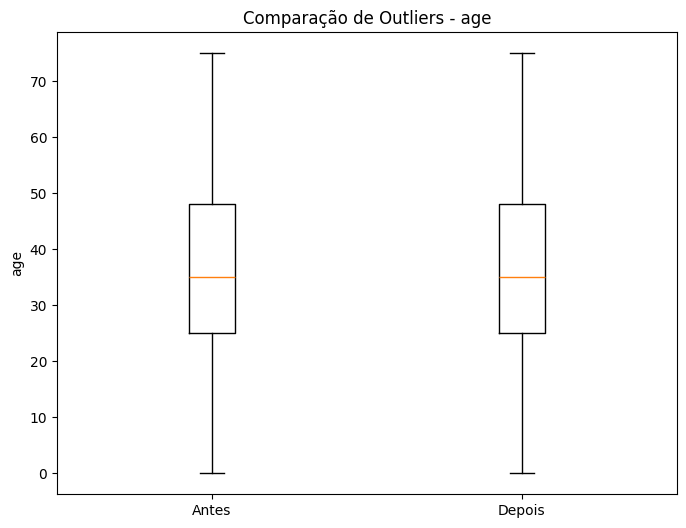

In [ ]:

feature = 'age'

comparison = pd.DataFrame({
    'Antes': df_clean[feature],
    'Depois': df_out[feature]
})

plt.figure(figsize=(8, 6), edgecolor="steelblue")
plt.boxplot(
    [comparison['Antes'].dropna(), comparison['Depois'].dropna()],
    tick_labels=['Antes', 'Depois']
)

plt.title(f'Comparação de Outliers - {feature}')
plt.ylabel(feature)

plt.show()

3.4 Viewing the results handling

Text(0, 0.5, 'Count')

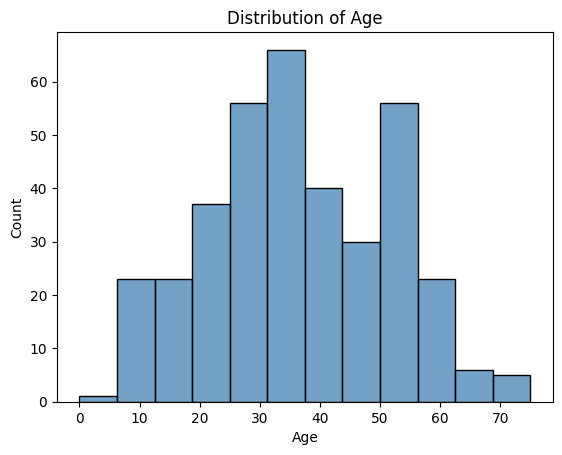

In [ ]:
sns.histplot(x=df_out['age'], color="steelblue") # shows the distribution of ages in the dataset using a histogram
plt.title("Distribution of Age") # title of the chart
plt.xlabel("Age") # label of the x-axis
plt.ylabel("Count") # label of the y-axis

3.5 Normalization the data

In [ ]:
# separe target before everything
X = df_out.drop(columns=[config["data"]["target_col"]]) # separates the features (all columns except 'class') and saves them in X
y = df_out[config["data"]["target_col"]] # separates the 'class' column as the target and saves it in y

# applies MinMaxScaler 
scaler = MinMaxScaler() # creates a MinMaxScaler object to normalize the data, transforming the values to a scale between 0 and 1
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) # applies the scaler to the X data and creates a new dataframe with the normalized values, keeping the same column names

# comparation before × after
print("BEFORE the normalization:")
print(X[['age', 'itching', 'scaling']].describe().round(2)) # shows basic statistics for the 'age', 'itching', and 'scaling' columns before normalization, rounding the values to 2 decimal places

print("\nAFTER the normalization:")
print(X_scaled[['age', 'itching', 'scaling']].describe().round(2)) # shows basic statistics for the 'age', 'itching', and 'scaling' columns after normalization, rounding the values to 2 decimal places, confirming that the values have been transformed to a scale between 0 and 1

ANTES da normalização:
          age  itching  scaling
count  366.00   366.00    366.0
mean    36.27     1.37      1.8
std     15.16     1.14      0.7
min      0.00     0.00      0.0
25%     25.00     0.00      1.0
50%     35.00     1.00      2.0
75%     48.00     2.00      2.0
max     75.00     3.00      3.0

DEPOIS da normalização:
          age  itching  scaling
count  366.00   366.00   366.00
mean     0.48     0.46     0.60
std      0.20     0.38     0.23
min      0.00     0.00     0.00
25%      0.33     0.00     0.33
50%      0.47     0.33     0.67
75%      0.64     0.67     0.67
max      1.00     1.00     1.00


In [ ]:
wandb.init(project="mlops-project-dermatology", job_type="scaled_data", name="scaled_data") 
artifact = wandb.Artifact("scaled_data", type="dataset") # new artifact for clean data
df_stand = X_scaled.copy() # creates a new dataframe df_stand from X_scaled to add the class column back before saving the artifact
df_stand['class'] = y.values # adds the 'class' column back to the df_stand dataframe so that the normalized dataset has both features and target before saving the artifact
temp_stand = "temp_scaled.csv" # temporary path to save the CSV of the cleaned dataframe
df_stand.to_csv(temp_stand, index=False) # saves the dataframe to a CSV file and prevents the index from being saved as a column
artifact.add_file(temp_stand) # adds the CSV file of the cleaned dataframe to the artifact
wandb.log_artifact(artifact) # logs the artifact to W&B
#wandb.summary["clean_rows"] = len(df_c) # adds to the W&B summary the number of rows of the cleaned dataset
wandb.finish() # finishes the current run in W&B
print("Dataset scaled and saved with artifact in W&B.")

Dataset normalizado salvo como artifact no W&B.


# 4. Features Selection

4.1 Preparation for feature selection

4.1.1 Method 1: Pearson Correlation

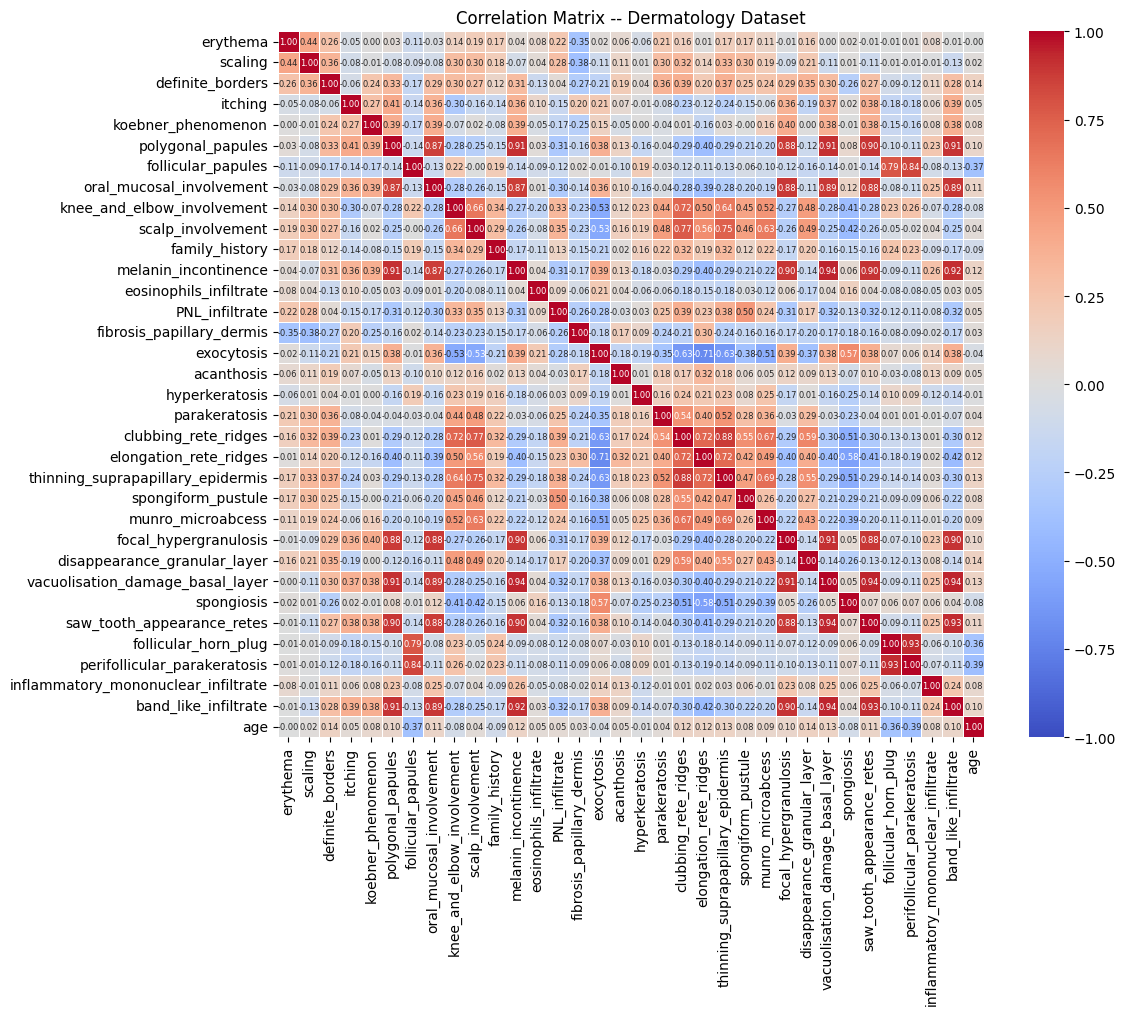

Top 10 features by Correlation:
thinning_suprapapillary_epidermis    0.684864
clubbing_rete_ridges                 0.668781
PNL_infiltrate                       0.550195
scalp_involvement                    0.533208
fibrosis_papillary_dermis            0.526976
munro_microabcess                    0.520995
follicular_papules                   0.477813
scaling                              0.468688
perifollicular_parakeratosis         0.457025
spongiform_pustule                   0.449407
dtype: float64


In [ ]:
corr_matrix = df_out.drop(columns=[config["data"]["target_col"]]).corr() # calcule the matrix
# calculates the correlation matrix between the features, excluding the 'class' target column to focus only on the relationships between the features
 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', # shows the correlation matrix using a heatmap, with the values annotated and formatted to 2 decimal places, using the 'coolwarm' color palette to highlight positive and negative correlations
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            annot_kws={"size": 6})
plt.title('Correlation Matrix -- Dermatology Dataset')
plt.tight_layout()
corr_fig_path = "correlation_matrix.png"
plt.savefig(corr_fig_path, dpi=150)
plt.show()

# Guardar como corr_series (com .abs())
corr_series = df_out.drop(columns=[config["data"]["target_col"]]) \
                    .corrwith(df_out[config["data"]["target_col"]]) \
                    .abs() \
                    .sort_values(ascending=False)

print("Top 10 features by Correlation:")
print(corr_series.head(10))

In [ ]:
# Log to W&B as an image artifact
wandb.init(project="mlops-regression-feature-selection", job_type="eda", name="correlation_matrix")
wandb.log({"correlation_matrix": wandb.Image(corr_fig_path)})
wandb.finish()
print("Correlation matrix image saved and logged in W&B.")

Correlation matrix imagem salva e logada no W&B.


4.1.2 Method 2: Mutual Information

In [ ]:
mi_scores = mutual_info_classif(X, y, random_state=42) # calculates the importance of features using mutual information, which measures the dependency between each feature and the target, returning an array of scores for each feature
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("Top 10 features by Mutual Information:")
print(mi_series.head(10))

Top 10 features by Mutual Information:
elongation_rete_ridges               0.578766
clubbing_rete_ridges                 0.568074
thinning_suprapapillary_epidermis    0.534654
saw_tooth_appearance_retes           0.503324
melanin_incontinence                 0.499348
band_like_infiltrate                 0.491631
focal_hypergranulosis                0.478665
vacuolisation_damage_basal_layer     0.462895
oral_mucosal_involvement             0.415473
polygonal_papules                    0.411888
dtype: float64


4.1.3 Method 3: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=config["data"]["random_state"]) # create a Random Forest model for classification with 100 trees and a defined seed for reproducibility
rf.fit(X, y) # train the Random Forest model using the X and y data, learning the relationship between the features and the target to calculate the importance of each feature
rf_series = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 features by Random Forest Importance:")
print(rf_series.head(10))

Top 10 features by Random Forest Importance:
thinning_suprapapillary_epidermis    0.085159
fibrosis_papillary_dermis            0.083784
clubbing_rete_ridges                 0.083688
elongation_rete_ridges               0.064522
koebner_phenomenon                   0.063152
spongiosis                           0.048175
saw_tooth_appearance_retes           0.039732
vacuolisation_damage_basal_layer     0.038646
PNL_infiltrate                       0.035923
band_like_infiltrate                 0.035742
dtype: float64


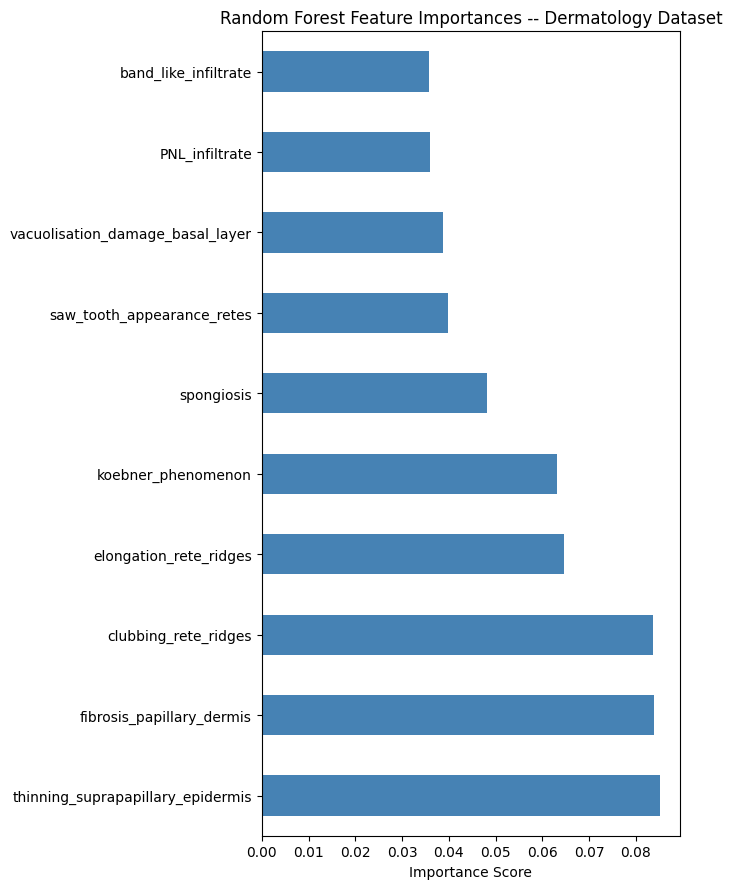

In [25]:
plt.figure(figsize=(7, 9))  
rf_series.head(10).plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importances -- Dermatology Dataset')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

4.2 Combine and Normalize

In [ ]:
def normalize(s):
    # normalize a Series to scale 0-1 (Min-Max)
    return (s - s.min()) / (s.max() - s.min())

corr_norm = normalize(corr_series)
mi_norm   = normalize(mi_series)
rf_norm   = normalize(rf_series)

# Score final = média dos 3 métodos normalizados
combined        = (corr_norm + mi_norm + rf_norm) / 3
combined_sorted = combined.sort_values(ascending=False)

print("TOP 15 FEATURES — SCORE COMBINADED")
print(combined_sorted.head(15).round(3))

TOP 15 FEATURES — SCORE COMBINADO
clubbing_rete_ridges                 0.980
thinning_suprapapillary_epidermis    0.975
fibrosis_papillary_dermis            0.803
elongation_rete_ridges               0.754
PNL_infiltrate                       0.586
scalp_involvement                    0.521
knee_and_elbow_involvement           0.510
spongiosis                           0.504
munro_microabcess                    0.497
exocytosis                           0.488
saw_tooth_appearance_retes           0.463
band_like_infiltrate                 0.438
perifollicular_parakeratosis         0.438
vacuolisation_damage_basal_layer     0.433
koebner_phenomenon                   0.432
dtype: float64


In [ ]:
ranking_df = pd.DataFrame({
    'Correlacao'    : corr_norm,
    'Mutual_Info'   : mi_norm,
    'Random_Forest' : rf_norm,
    'Score_Final'   : combined
}).sort_values('Score_Final', ascending=False)

print("\nCOMPARATIVE TABLE COMPLETE (normalized scores 0 to 1):")
print(ranking_df.round(3).to_string())


TABELA COMPARATIVA COMPLETA (scores normalizados 0 a 1):
                                     Correlacao  Mutual_Info  Random_Forest  Score_Final
clubbing_rete_ridges                      0.976        0.982          0.982        0.980
thinning_suprapapillary_epidermis         1.000        0.924          1.000        0.975
fibrosis_papillary_dermis                 0.762        0.663          0.984        0.803
elongation_rete_ridges                    0.508        1.000          0.754        0.754
PNL_infiltrate                            0.797        0.548          0.413        0.586
scalp_involvement                         0.772        0.599          0.192        0.521
knee_and_elbow_involvement                0.546        0.693          0.290        0.510
spongiosis                                0.290        0.664          0.559        0.504
munro_microabcess                         0.753        0.481          0.257        0.497
exocytosis                                0.396     

4.3 Exclusion of highly correlated features (VIF)

In [ ]:
def calculate_vif(df_features):
    # calculate the Variance Inflation Factor (VIF) for each feature in the dataframe.
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_features.values, i)
        for i in range(df_features.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


In [ ]:
# Get the top 15 features by combined score to analyze VIF
top15_features = combined_sorted.head(15).index.tolist()
X_top15 = X[top15_features]

vif_df = calculate_vif(X_top15)
high_vif_features = vif_df[vif_df['VIF'] > 10]['feature'].tolist()

print(f"\nVIF calculated for the top 15 features:")
print(vif_df.to_string(index=False))
print(f"\nFeatures with VIF > 10 (will be removed): {high_vif_features}")


VIF calculado para as top 15 features:
                          feature       VIF
 vacuolisation_damage_basal_layer 14.283817
             band_like_infiltrate 12.760680
       saw_tooth_appearance_retes 12.454022
             clubbing_rete_ridges  9.878832
thinning_suprapapillary_epidermis  8.469940
           elongation_rete_ridges  8.144676
       knee_and_elbow_involvement  4.228713
                       exocytosis  4.198537
                scalp_involvement  3.813594
                munro_microabcess  2.782592
                       spongiosis  2.764818
        fibrosis_papillary_dermis  2.607361
               koebner_phenomenon  1.973728
                   PNL_infiltrate  1.868945
     perifollicular_parakeratosis  1.559091

Features com VIF > 10 (serão removidas): ['vacuolisation_damage_basal_layer', 'band_like_infiltrate', 'saw_tooth_appearance_retes']


4.4 Final Canditates

In [ ]:
candidates = combined_sorted.head(10).index.tolist()
final_features = [f for f in candidates if f not in high_vif_features]

print("\n" + "="*55)
print("FINAL FEATURES SELECTED FOR THE MLP")
print("="*55)
for i, f in enumerate(final_features, 1):
    print(f"  {i:2d}. {f}  (score: {combined_sorted[f]:.3f})")
print(f"\nTotal: {len(final_features)} features")


FEATURES FINAIS SELECIONADAS PARA A MLP
   1. clubbing_rete_ridges  (score: 0.980)
   2. thinning_suprapapillary_epidermis  (score: 0.975)
   3. fibrosis_papillary_dermis  (score: 0.803)
   4. elongation_rete_ridges  (score: 0.754)
   5. PNL_infiltrate  (score: 0.586)
   6. scalp_involvement  (score: 0.521)
   7. knee_and_elbow_involvement  (score: 0.510)
   8. spongiosis  (score: 0.504)
   9. munro_microabcess  (score: 0.497)
  10. exocytosis  (score: 0.488)

Total: 10 features


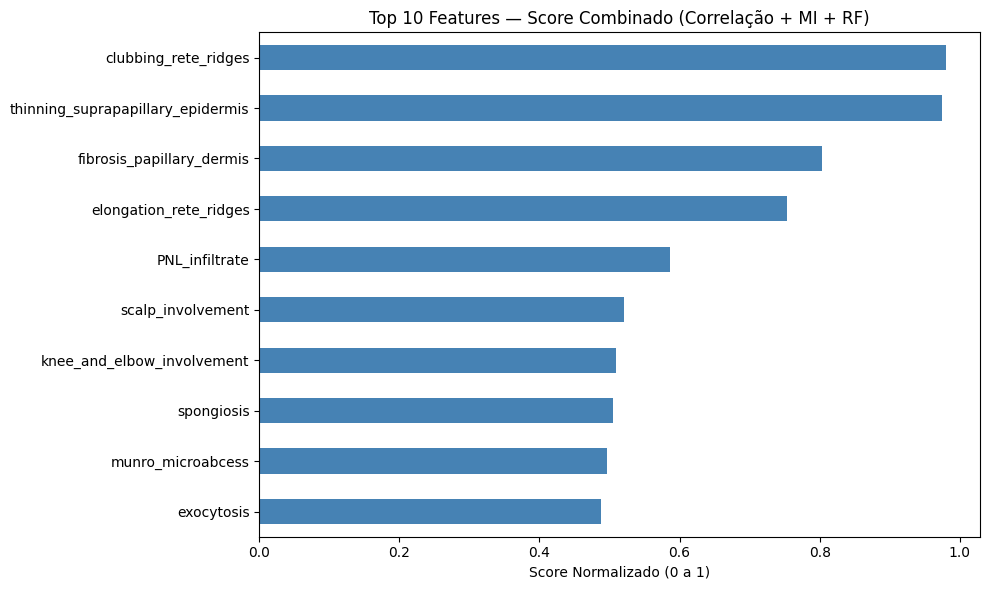

In [35]:
plt.figure(figsize=(10, 6))
combined_sorted.head(10).sort_values().plot(
    kind='barh', color='steelblue'
)
plt.title('Top 10 Features — Score Combinado (Correlação + MI + RF)')
plt.xlabel('Score Normalizado (0 a 1)')
plt.tight_layout()
plt.savefig("feature_ranking.png", dpi=150)
plt.show()

In [ ]:
wandb.init(
    project="mlops-project-dermatology",
    job_type="feature_selection",
    name="feature_selection"
)

# Comparative table
wandb.log({
    "feature_ranking_table": wandb.Table(
        dataframe=ranking_df.reset_index().rename(
            columns={'index': 'feature'}
        ).round(3)
    )
})

# Table for VIF
wandb.log({
    "vif_table": wandb.Table(dataframe=vif_df)
})

# Graphic for feature ranking
wandb.log({"feature_ranking_plot": wandb.Image("feature_ranking.png")})

# Features selecionadas nos configs
wandb.config.update({
    "selected_features"  : final_features,
    "n_features_selected": len(final_features),
    "removed_high_vif"   : high_vif_features
})

wandb.finish()
print("\n✅ Feature selection completed and saved to W&B!")


✅ Feature selection completa e salva no W&B!


# 5. Train‑Test Split

5.1 Division

In [30]:
def split_train_test(
    df,
    target_col,
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"]
):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    test_df = X_test.copy()
    test_df[target_col] = y_test

    return train_df, test_df

In [ ]:
from scipy.stats import ks_2samp, chi2_contingency

def compare_distributions(train_df, test_df, columns): # compare the distributions of features between the train and test datasets using KS for numerical and Chi2 for categorical
    results = {}
    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals  = test_df[col].dropna()

        if train_df[col].dtype in ['int64', 'float64']: 
            # KS test for numerical continuous variables
            ks_stat, p_value = ks_2samp(train_vals, test_vals)
            results[col] = {
                'test'     : 'KS',
                'statistic': round(ks_stat, 4),
                'p_value'  : round(p_value, 4)
            }
        else:
            # Chi2 for categorical variables
            all_cats    = sorted(set(train_vals).union(set(test_vals)))
            train_counts = [train_vals.value_counts().get(cat, 0) for cat in all_cats]
            test_counts  = [test_vals.value_counts().get(cat,  0) for cat in all_cats]
            chi2, p_value, _, _ = chi2_contingency([train_counts, test_counts]) 
            results[col] = {
                'test'     : 'Chi2',
                'statistic': round(chi2, 4), # rounds the chi2 value to 4 decimal places
                'p_value'  : round(p_value, 4)
            }

    return results
train_df, test_df = split_train_test(
    df_out,
    target_col=config["data"]["target_col"],
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"]
)

feature_cols = [
    c for c in train_df.columns
    if c != config["data"]["target_col"]
]

# Usar train_df e test_df que foram retornados
print(f"Train: {len(train_df)} amostras")
print(f"Test:  {len(test_df)} amostras")

comp_results = compare_distributions(train_df, test_df, feature_cols)

# Show results
results_df = pd.DataFrame(comp_results).T
print(results_df)

Treino: 292 amostras
Teste:  74 amostras
                                    test statistic p_value
erythema                              KS    0.0903  0.6806
scaling                               KS    0.0274     1.0
definite_borders                      KS    0.0559  0.9865
itching                               KS    0.0607  0.9697
koebner_phenomenon                    KS    0.0244     1.0
polygonal_papules                     KS    0.0212     1.0
follicular_papules                    KS    0.0263     1.0
oral_mucosal_involvement              KS    0.0123     1.0
knee_and_elbow_involvement            KS    0.0398  0.9999
scalp_involvement                     KS    0.0414  0.9998
family_history                        KS     0.039  0.9999
melanin_incontinence                  KS     0.013     1.0
eosinophils_infiltrate                KS    0.0369     1.0
PNL_infiltrate                        KS    0.0248     1.0
fibrosis_papillary_dermis             KS     0.028     1.0
exocytosis     

In [39]:
wandb.init(project="mlops-wandb-demo", job_type="split_data", name="split_data")

train_artifact = wandb.Artifact("train_data", type="dataset")
train_df.to_csv("temp_train.csv", index=False)
train_artifact.add_file("temp_train.csv")
wandb.log_artifact(train_artifact)

test_artifact = wandb.Artifact("test_data", type="dataset")
test_df.to_csv("temp_test.csv", index=False)
test_artifact.add_file("temp_test.csv")
wandb.log_artifact(test_artifact)

comp_df = pd.DataFrame(comp_results).T
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len(test_df)

wandb.finish()
print("Artefatos de treino e teste salvos com sucesso.")

test_size,74
train_size,292


Artefatos de treino e teste salvos com sucesso.


# 6. Model MLP

6.1 Arquitetura da MLP

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Arquitetura da MLP 
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim=6, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h)) # camada linear (fully connected)
            layers.append(nn.BatchNorm1d(h))   # estabiliza treino
            layers.append(nn.ReLU())         # ativações não lineares
            layers.append(nn.Dropout(dropout)) # reativado — importante para regularização
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

6.2 Preparação do carregamento dos dados

In [41]:
def prepare_dataloaders(train_df, test_df, target_col, batch_size):

    X_train = train_df.drop(columns=[target_col]).values
    X_test  = test_df.drop(columns=[target_col]).values
    y_train = train_df[target_col].values
    y_test  = test_df[target_col].values

    # Normalizar apenas as features
    scaler  = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ✅ y como long 1D e classes 0-5
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_train_t = torch.tensor(y_train - 1, dtype=torch.long)  # 1-6 → 0-5
    y_test_t  = torch.tensor(y_test  - 1, dtype=torch.long)

    # Verificação de shapes
    print(f"X_train shape: {X_train_t.shape}")          # [292, 10]
    print(f"y_train shape: {y_train_t.shape}")          # [292]
    print(f"Classes únicas: {y_train_t.unique()}")      # [0,1,2,3,4,5]

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size, shuffle=False
    )
    return train_loader, test_loader, scaler

6.3 Função de treino do modelo

In [42]:
def train_model(config, train_loader, test_loader, input_dim):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = MLP(
        input_dim,
        config['model']['hidden_sizes'],
        output_dim=config['model']['output_dim'],
        dropout=config['model']['dropout']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['training']['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    best_loss = float('inf')
    patience  = config['training']['early_stopping_patience']
    counter   = 0

    wandb.watch(model, log="all")

    for epoch in range(config['training']['epochs']):

        # ── Treino ────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss   = criterion(output, y_batch)  # CrossEntropy espera [N,6] e [N]
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # ── Validação ─────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        correct  = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output   = model(X_batch)
                loss     = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)


                pred     = output.argmax(dim=1)
                correct += (pred == y_batch).sum().item()

        val_loss /= len(test_loader.dataset)
        acc       = correct / len(test_loader.dataset)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1:3d}] | Train Loss: {train_loss:.4f} "
                  f"| Val Loss: {val_loss:.4f} | Val Acc: {acc:.3f}")

        wandb.log({
            "epoch"     : epoch + 1,
            "train_loss": train_loss,
            "val_loss"  : val_loss,
            "val_acc"   : acc,
            "lr"        : optimizer.param_groups[0]['lr']
        })

        # ── Early Stopping ────────────────────────────────────
        if val_loss < best_loss:
            best_loss = val_loss
            counter   = 0
            torch.save(model.state_dict(), "best_model.pt")
            model_artifact = wandb.Artifact("trained_model", type="model")
            model_artifact.add_file("best_model.pt")
            wandb.log_artifact(model_artifact)
        else:
            counter += 1
            if counter >= patience:
                print(f"⏹️ Early stopping na época {epoch+1}")
                break

    # ✅ weights_only=True evita warning em PyTorch novo
    #model.load_state_dict(torch.load("best_model.pt", weights_only=True))
    return model

6.3 Função de integração do Sweep

In [ ]:
def train():
    wandb.init()

    sweep_params = wandb.config

    local_config = config.copy()
    # Atualiza os hiperparâmetros do config com os valores do sweep
    local_config["model"]["hidden_sizes"] = sweep_params.hidden_sizes
    local_config["model"]["dropout"] = sweep_params.dropout
    local_config["training"]["learning_rate"] = sweep_params.learning_rate
    local_config["training"]["batch_size"] = sweep_params.batch_size

    train_df_mlp = train_df[final_features + [config["data"]["target_col"]]]
    test_df_mlp  = test_df[final_features + [config["data"]["target_col"]]]

    train_loader, test_loader, scaler = prepare_dataloaders(
        train_df_mlp,
        test_df_mlp,
        config["data"]["target_col"],
        local_config["training"]["batch_size"]
    )

    input_dim = train_loader.dataset.tensors[0].shape[1]
    
    model = train_model(
        local_config,
        train_loader,
        test_loader,
        input_dim
    )

    wandb.finish()

In [ ]:
# Inicia o sweep no W&B usando a configuração definida
sweep_id = wandb.sweep(
    sweep_config,
    project="mlops-project-dermatology"
)

In [ ]:
# Executa o agente do W&B para rodar a função de treinamento com os hiperparâmetros definidos no sweep, repetindo por 10 vezes para explorar diferentes combinações
wandb.agent(
    sweep_id, 
    function=train, 
    count=10
)

wandb: ERROR Error while calling W&B API: project not found (<Response [404]>)


UsageError: project not found

6.4 Busca pelo melhor parâmetro com o Sweep

In [ ]:
import wandb
api = wandb.Api()

# Busca todos os runs do sweep e pega o melhor por val_acc
sweep = api.sweep(f"raycoelho-ufrn/mlops-project-dermatology/{sweep_id}")
best_run = sweep.best_run(order="val_acc")

print("=" * 50)
print(f"Melhor run: {best_run.name}")
print(f"val_acc:    {best_run.summary.get('val_acc', 'N/A'):.4f}")
print(f"val_loss:   {best_run.summary.get('val_loss', 'N/A'):.4f}")
print("\nMelhores hiperparâmetros:")
best_params = best_run.config
for k, v in best_params.items():
    print(f"  {k}: {v}")

wandb: Sorting runs by -summary_metrics.val_acc


Melhor run: volcanic-sweep-8
val_acc:    0.8514
val_loss:   0.3343

Melhores hiperparâmetros:
  dropout: 0.1
  batch_size: 64
  hidden_sizes: [256, 128]
  learning_rate: 0.01


6.5 Atualizando a config

In [ ]:
config["model"]["hidden_sizes"]       = best_params["hidden_sizes"]
config["model"]["dropout"]            = best_params["dropout"]
config["training"]["learning_rate"]   = best_params["learning_rate"]
config["training"]["batch_size"]      = best_params["batch_size"]

print("\nConfig atualizado com os melhores hiperparâmetros!")


Config atualizado com os melhores hiperparâmetros!


6.6 Treinamento com os melhores parâmetros

In [ ]:
wandb.init(
    project="mlops-project-dermatology",
    job_type="final_train",
    name="best_model_final",
    config=config
)

train_df_mlp = train_df[final_features + [config["data"]["target_col"]]]
test_df_mlp  = test_df[final_features  + [config["data"]["target_col"]]]

train_loader, test_loader, scaler = prepare_dataloaders(
    train_df_mlp, test_df_mlp,
    config["data"]["target_col"],
    config["training"]["batch_size"]
)

input_dim = train_loader.dataset.tensors[0].shape[1]
model     = train_model(config, train_loader, test_loader, input_dim)

# ✅ Salvar com o nome correto
torch.save(model.state_dict(), "best_model_final.pt")
print("✅ Modelo final treinado e salvo!")
wandb.finish()

NameError: name 'wandb' is not defined

# 7. Avaliação Completa

7.1 Avaliação

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # garante que o modelo e os dados sejam movidos para a GPU se disponível, caso contrário, usa a CPU

In [ ]:
model = MLP(
    input_dim    = len(final_features),
    hidden_sizes = config["model"]["hidden_sizes"],
    output_dim   = config["model"]["output_dim"],
    dropout      = config["model"]["dropout"]
).to(device)

model.load_state_dict(torch.load("best_model_final.pt", weights_only=True))
model.eval() # coloca o modelo em modo de avaliação, desativando dropout e batchnorm para garantir previsões consistentes durante a avaliação
print("✅ Modelo carregado!")

✅ Modelo carregado!


In [ ]:

all_preds  = [] # lista para armazenar as previsões do modelo
all_labels = [] # lista para armazenar os rótulos verdadeiros
all_probs  = [] # lista para armazenar as probabilidades previstas para cada classe, que serão usadas para calcular métricas como ROC AUC

with torch.no_grad():
    for X_batch, y_batch in test_loader: # itera sobre os batches do dataloader de teste, onde X_batch são as features e y_batch são os rótulos verdadeiros para aquele batch
        X_batch = X_batch.to(device) # move o batch de features para o mesmo dispositivo do modelo (GPU ou CPU)
        output  = model(X_batch) # obtém as saídas do modelo para o batch atual, que são os logits (valores antes da função softmax) para cada classe
        probs   = torch.softmax(output, dim=1)  # probabilidades por classe
        preds   = output.argmax(dim=1) # obtém as previsões do modelo para o batch atual, que são os índices das classes com a maior probabilidade prevista

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)   # converte a lista de previsões para um array numpy para facilitar o cálculo das métricas
all_labels = np.array(all_labels)  # converte a lista de rótulos verdadeiros para um array numpy para facilitar o cálculo das métricas
all_probs  = np.array(all_probs)

# Nomes das classes (0-5 → Classe 1-6)
class_names = [f"Classe {i+1}" for i in range(6)]

7.2 Métricas

In [ ]:
acc       = accuracy_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

try:
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
except:
    auc = 0.0

print("\n" + "=" * 50)
print("MÉTRICAS FINAIS — MODELO MLP")
print("=" * 50)
print(f"Acurácia  : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}")
print(f"Precisão  : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)}")


MÉTRICAS FINAIS — MODELO MLP
Acurácia  : 0.8378 (83.78%)
F1-Score  : 0.8336
Precisão  : 0.8448
Recall    : 0.8378
AUC-ROC   : 0.9719

              precision    recall  f1-score   support

    Classe 1       1.00      1.00      1.00        23
    Classe 2       0.88      0.58      0.70        12
    Classe 3       0.68      0.87      0.76        15
    Classe 4       0.56      0.50      0.53        10
    Classe 5       1.00      1.00      1.00        10
    Classe 6       0.80      1.00      0.89         4

    accuracy                           0.84        74
   macro avg       0.82      0.83      0.81        74
weighted avg       0.84      0.84      0.83        74



7.3 Matriz de Confusão

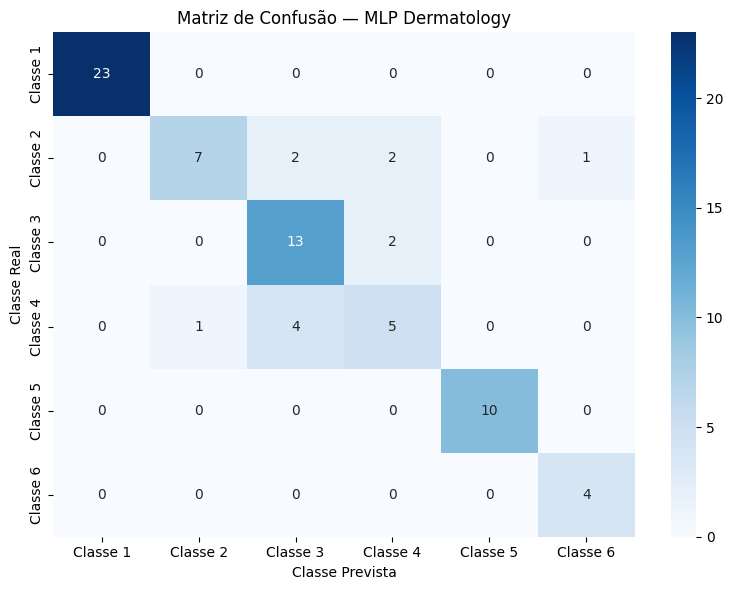

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão — MLP Dermatology')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

7.4 Logar no W&B

In [ ]:
wandb.init(
    project="mlops-project-dermatology",
    job_type="evaluation",
    name="final_evaluation"
)

wandb.log({
    "test_accuracy" : acc,
    "test_f1"       : f1,
    "test_precision": precision,
    "test_recall"   : recall,
    "test_auc_roc"  : auc,
    "confusion_matrix": wandb.Image("confusion_matrix.png")
})

# Tabela de métricas por classe
report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T.reset_index()
report_df.columns = ['classe'] + list(report_df.columns[1:])
wandb.log({"metrics_per_class": wandb.Table(dataframe=report_df.round(3))})

# Salvar modelo final como artefato
artifact = wandb.Artifact(
    name="mlp_dermatology_final",
    type="model",
    description=f"MLP final — acc={acc:.4f} f1={f1:.4f} auc={auc:.4f}"
)
artifact.add_file("best_model_final.pt")
wandb.log_artifact(artifact)

wandb.finish()
print("\n🏁 Avaliação completa salva no W&B!")

test_accuracy,▁
test_auc_roc,▁
test_f1,▁
test_precision,▁
test_recall,▁
test_accuracy,0.83784
test_auc_roc,0.97187
test_f1,0.83364
test_precision,0.84485
test_recall,0.83784



🏁 Avaliação completa salva no W&B!
